# SMS Spam Detection

**Objective:** Classify SMS messages as spam or ham (legitimate) using NLP-based feature extraction and machine learning classifiers.

**Dataset:** UCI SMS Spam Collection — 5,572 messages labeled ham/spam.

**Approach:**
- Preprocess raw text (normalize, remove noise, stem)
- Extract TF-IDF features combined with hand-crafted metadata features (length, digit ratio, etc.)
- Train Naive Bayes (baseline), Logistic Regression, and Random Forest
- Evaluate with precision, recall, F1, ROC-AUC — critical here because false negatives (missed spam) and false positives (blocking legitimate messages) have different costs
- Tune best model with GridSearchCV

## 1. Imports

In [4]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)
from scipy.sparse import hstack, csr_matrix

nltk.download('stopwords', quiet=True)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 100)

## 2. Load Data

In [ ]:
# Tab-separated, no header; latin-1 encoding handles non-ASCII characters in the original file
df = pd.read_csv(
    'data/SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'message'],
    encoding='latin-1'
)

print('Shape:', df.shape)

Shape: (5572, 2)


In [ ]:
print('Class distribution:')
print(df['label'].value_counts())


Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [7]:
df.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
5,spam,FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for ...
6,ham,Even my brother is not like to speak with me. They treat me like aids patent.
7,ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your call...
8,spam,WINNER!! As a valued network customer you have been selected to receivea Â£900 prize reward! To ...
9,spam,Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with came...


In [ ]:
print(f'Spam rate: {df["label"].eq("spam").mean():.2%}')


Spam rate: 13.41%


## 3. Exploratory Data Analysis

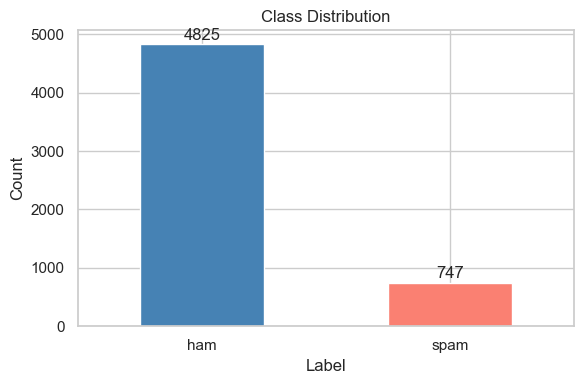

In [9]:
# Class imbalance — ~87% ham, ~13% spam
# Important: precision/recall matter more than accuracy here
fig, ax = plt.subplots(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Class Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', va='bottom')
plt.tight_layout()
plt.show()

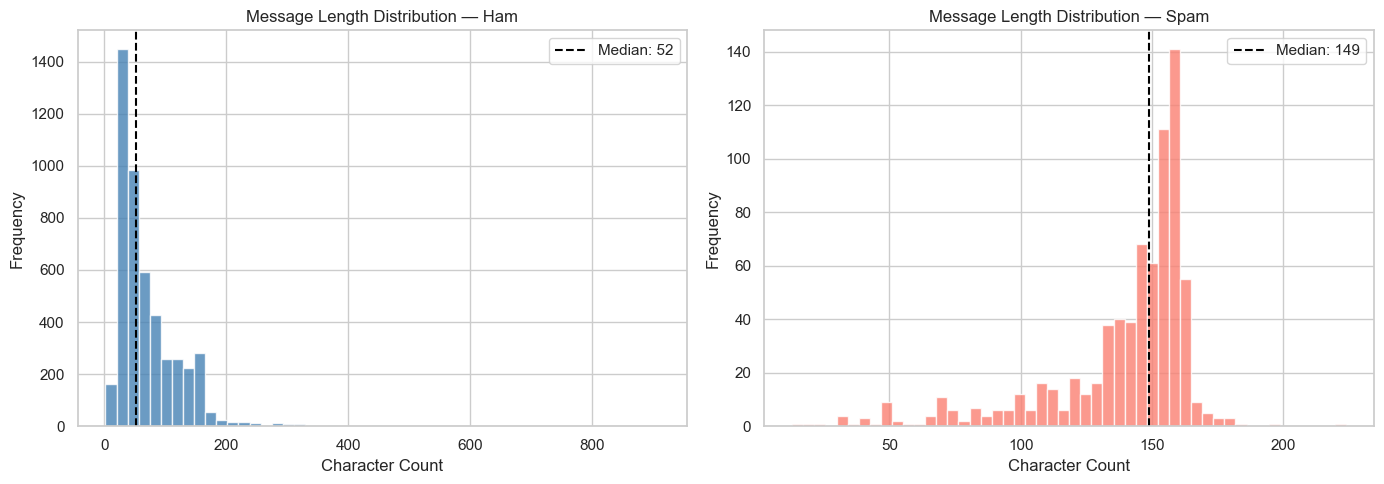

In [10]:
# Message length is a strong spam signal — spam tends to be longer and more structured
df['msg_length'] = df['message'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in zip(axes, ['ham', 'spam'], ['steelblue', 'salmon']):
    subset = df[df['label'] == label]['msg_length']
    ax.hist(subset, bins=50, color=color, alpha=0.8)
    ax.set_title(f'Message Length Distribution — {label.capitalize()}')
    ax.set_xlabel('Character Count')
    ax.set_ylabel('Frequency')
    ax.axvline(subset.median(), color='black', linestyle='--', label=f'Median: {subset.median():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

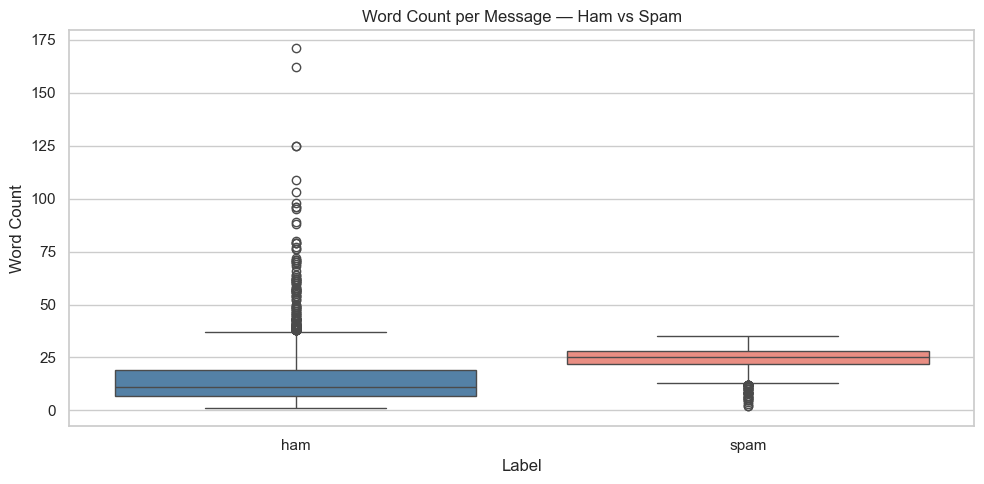

In [11]:
# Word count distribution per class
df['word_count'] = df['message'].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='label', y='word_count', palette={'ham': 'steelblue', 'spam': 'salmon'})
plt.title('Word Count per Message — Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

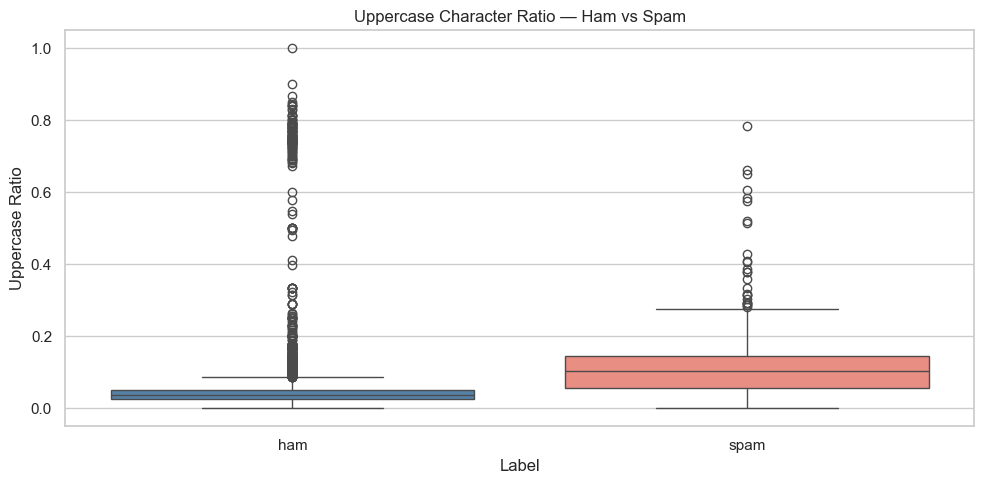

In [12]:
# Uppercase ratio — spam messages often use caps for urgency (e.g. FREE, WINNER, URGENT)
df['upper_ratio'] = df['message'].apply(
    lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='label', y='upper_ratio', palette={'ham': 'steelblue', 'spam': 'salmon'})
plt.title('Uppercase Character Ratio — Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Uppercase Ratio')
plt.tight_layout()
plt.show()

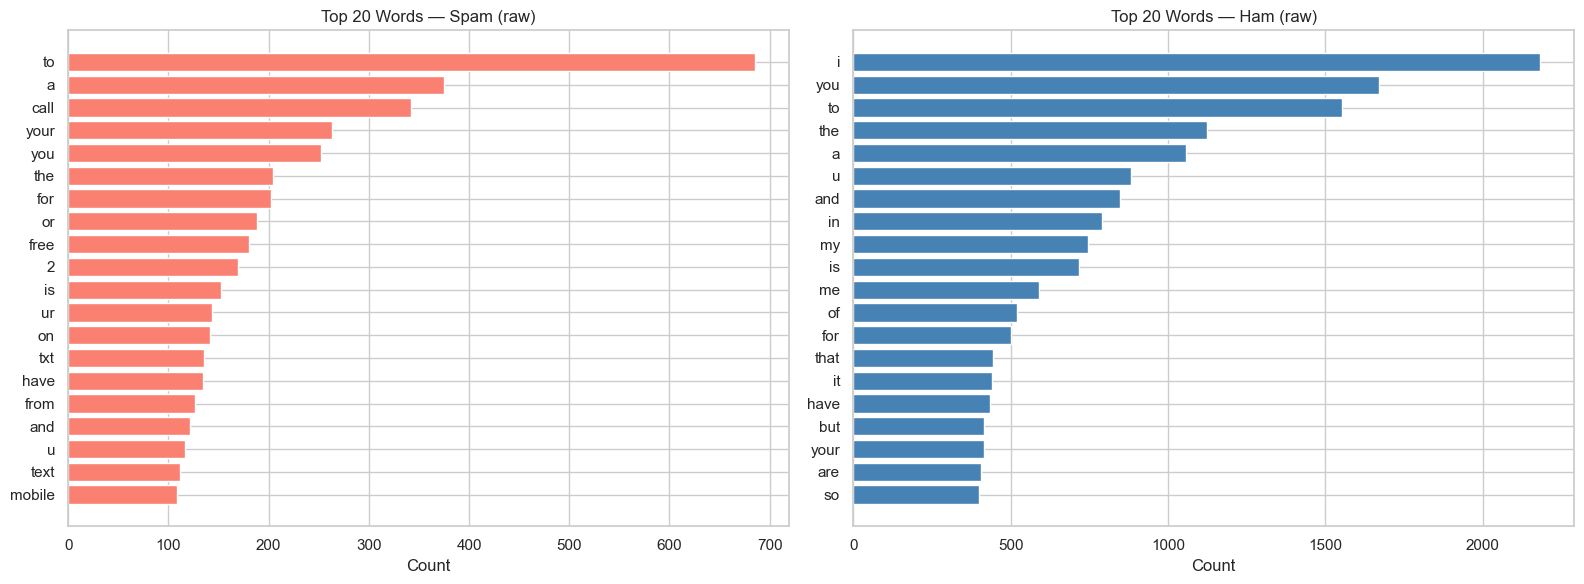

In [13]:
# Top 20 words in spam vs ham (raw, before cleaning) to motivate preprocessing
from collections import Counter

def top_words(series, n=20):
    words = ' '.join(series).lower().split()
    return pd.DataFrame(Counter(words).most_common(n), columns=['word', 'count'])

spam_words = top_words(df[df['label'] == 'spam']['message'])
ham_words  = top_words(df[df['label'] == 'ham']['message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(spam_words['word'][::-1], spam_words['count'][::-1], color='salmon')
axes[0].set_title('Top 20 Words — Spam (raw)')
axes[0].set_xlabel('Count')

axes[1].barh(ham_words['word'][::-1], ham_words['count'][::-1], color='steelblue')
axes[1].set_title('Top 20 Words — Ham (raw)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 4. Data Cleaning & Text Preprocessing

In [14]:
stemmer   = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text: str) -> str:
    """
    Clean and normalize a single SMS message.

    Steps:
    1. Lowercase — removes case-based duplicates (Free vs free vs FREE)
    2. Remove URLs — spam often embeds tracking/redirect links
    3. Remove phone numbers — common in spam call-to-action patterns
    4. Remove punctuation and digits — reduces vocabulary noise
    5. Tokenize and remove stopwords — keeps content words only
    6. Stem — collapses morphological variants (winning/winner/win → win)
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'\+?\d[\d\s\-().]{7,}\d', '', text) # remove phone numbers
    text = re.sub(r'[^a-z\s]', '', text)                # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess_text)

# Verify preprocessing on a known spam example
idx = df[df['label'] == 'spam'].index[0]
print('Original :', df.loc[idx, 'message'])
print('Cleaned  :', df.loc[idx, 'clean_message'])

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned  : free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over


In [15]:
# Encode target: spam=1, ham=0
df['target'] = (df['label'] == 'spam').astype(int)

print('Target distribution:')
print(df['target'].value_counts())

Target distribution:
target
0    4825
1     747
Name: count, dtype: int64


## 5. Feature Engineering

In [16]:
# Hand-crafted features that capture spam patterns beyond word frequencies
# These complement TF-IDF which cannot capture structural/stylistic signals

def extract_meta_features(text: str) -> dict:
    return {
        'msg_length':       len(text),
        'word_count':       len(text.split()),
        # digit ratio: spam often contains prize amounts, numbers, shortcodes
        'digit_ratio':      sum(c.isdigit() for c in text) / max(len(text), 1),
        # uppercase ratio: spam uses caps for urgency signals
        'upper_ratio':      sum(c.isupper() for c in text) / max(len(text), 1),
        # punctuation count: exclamation marks, currency symbols common in spam
        'punct_count':      sum(c in string.punctuation for c in text),
        # currency/special symbol presence
        'has_currency':     int(bool(re.search(r'[£$€]', text))),
        # exclamation marks: urgency marker in spam
        'exclaim_count':    text.count('!'),
        # question marks: less common in spam, more in conversation
        'question_count':   text.count('?'),
    }

meta_df = df['message'].apply(extract_meta_features).apply(pd.Series)
print('Meta features shape:', meta_df.shape)
meta_df.head()

Meta features shape: (5572, 8)


,msg_length,word_count,digit_ratio,upper_ratio,punct_count,has_currency,exclaim_count,question_count
0,111.0,20.0,0.00000,0.027027,9.0,0.0,0.0,0.0
1,29.0,6.0,0.00000,0.068966,6.0,0.0,0.0,0.0
2,155.0,28.0,0.16129,0.064516,6.0,0.0,0.0,0.0
3,49.0,11.0,0.00000,0.040816,6.0,0.0,0.0,0.0
4,61.0,13.0,0.00000,0.032787,2.0,0.0,0.0,0.0


## 6. Train/Test Split

In [17]:
X_text = df['clean_message']
X_meta = meta_df
y      = df['target']

# Stratify preserves the ~13% spam rate in both train and test splits
(
    X_text_train, X_text_test,
    X_meta_train, X_meta_test,
    y_train, y_test
) = train_test_split(
    X_text, X_meta, y,
    test_size=0.2, random_state=42, stratify=y
)

print('Train:', len(y_train), '| Test:', len(y_test))
print('Spam in test:', y_test.sum())

Train: 4457 | Test: 1115
Spam in test: 149


## 7. TF-IDF Vectorization

In [18]:
# TF-IDF with bigrams — captures two-word spam phrases like 'free entry', 'cash prize', 'call now'
# max_features limits vocabulary to top 5000 terms by corpus frequency
# min_df=2 drops terms that appear only once — reduces noise from typos/abbreviations

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    sublinear_tf=True   # apply log(1 + tf) — dampens effect of very frequent terms
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test  = tfidf.transform(X_text_test)

print('TF-IDF train matrix:', X_tfidf_train.shape)

TF-IDF train matrix: (4457, 5000)


In [19]:
# Scale meta features to [0,1] before combining with TF-IDF sparse matrix
# TF-IDF values are already bounded; unscaled meta features would dominate otherwise

scaler = MinMaxScaler()
X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_test_scaled  = scaler.transform(X_meta_test)

# Combine TF-IDF sparse matrix with dense meta features using scipy hstack
X_train_combined = hstack([X_tfidf_train, csr_matrix(X_meta_train_scaled)])
X_test_combined  = hstack([X_tfidf_test,  csr_matrix(X_meta_test_scaled)])

print('Combined train matrix:', X_train_combined.shape)

Combined train matrix: (4457, 5008)


## 8. Model Training

In [20]:
def evaluate(name: str, model, X_tr, y_tr, X_te, y_te) -> dict:
    """
    Fit model, predict on test set, return full metrics dict.
    Precision and recall reported separately — the cost of a false positive
    (blocking a real message) differs from a false negative (letting spam through).
    """
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else preds

    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_te, preds), 4),
        'Precision': round(precision_score(y_te, preds), 4),
        'Recall':    round(recall_score(y_te, preds), 4),
        'F1':        round(f1_score(y_te, preds), 4),
        'ROC-AUC':   round(roc_auc_score(y_te, proba), 4),
    }

In [21]:
# Multinomial NB requires non-negative input — use TF-IDF only (no meta features)
# because meta features after scaling are non-negative anyway, but NB is more
# interpretable as a pure text baseline without combining feature types
nb = MultinomialNB(alpha=0.1)  # alpha=0.1 (mild smoothing) better than default 1.0 for sparse text

# LR with class_weight='balanced' adjusts for the 87/13 class imbalance
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # same imbalance handling for RF
    random_state=42,
    n_jobs=-1
)

results  = []
fitted   = {}

# NB on TF-IDF only; LR and RF on combined features
model_configs = [
    ('Naive Bayes',          nb, X_tfidf_train,   X_tfidf_test),
    ('Logistic Regression',  lr, X_train_combined, X_test_combined),
    ('Random Forest',        rf, X_train_combined, X_test_combined),
]

for name, model, X_tr, X_te in model_configs:
    metrics = evaluate(name, model, X_tr, y_train, X_te, y_test)
    results.append(metrics)
    fitted[name] = (model, X_te)
    print(f"{name}: Acc={metrics['Accuracy']} | P={metrics['Precision']} | R={metrics['Recall']} | F1={metrics['F1']} | AUC={metrics['ROC-AUC']}")

results_df = pd.DataFrame(results).set_index('Model')
results_df

Naive Bayes: Acc=0.9794 | P=0.9846 | R=0.8591 | F1=0.9176 | AUC=0.9809
Logistic Regression: Acc=0.983 | P=0.9276 | R=0.9463 | F1=0.9369 | AUC=0.9916
Random Forest: Acc=0.9839 | P=1.0 | R=0.8792 | F1=0.9357 | AUC=0.9929


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Naive Bayes,0.9794,0.9846,0.8591,0.9176,0.9809
Logistic Regression,0.9830,0.9276,0.9463,0.9369,0.9916
Random Forest,0.9839,1.0000,0.8792,0.9357,0.9929


## 9. Evaluation

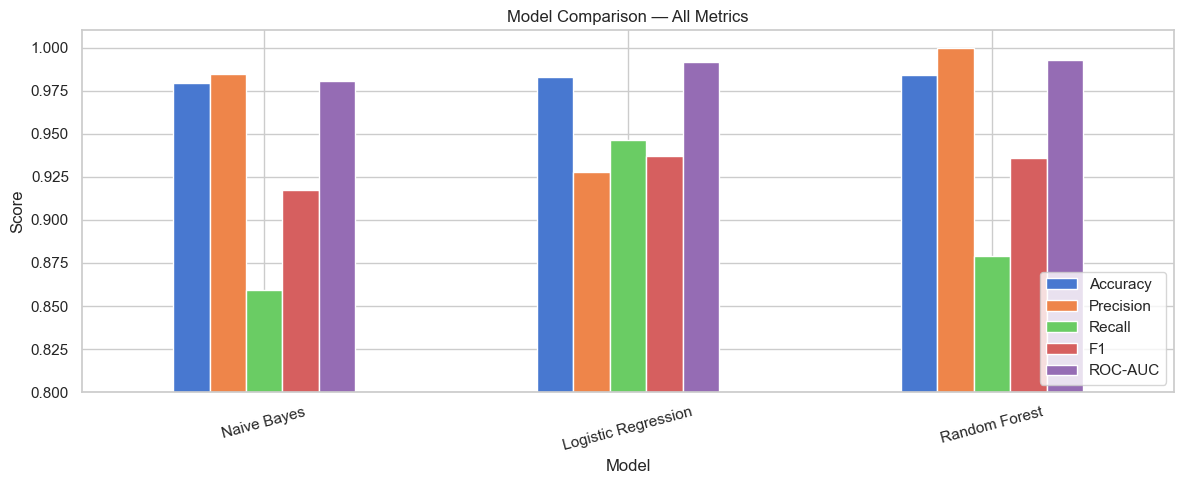

In [22]:
# Metric comparison — all five metrics side by side
results_df.plot(kind='bar', figsize=(12, 5), ylim=(0.8, 1.01))
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

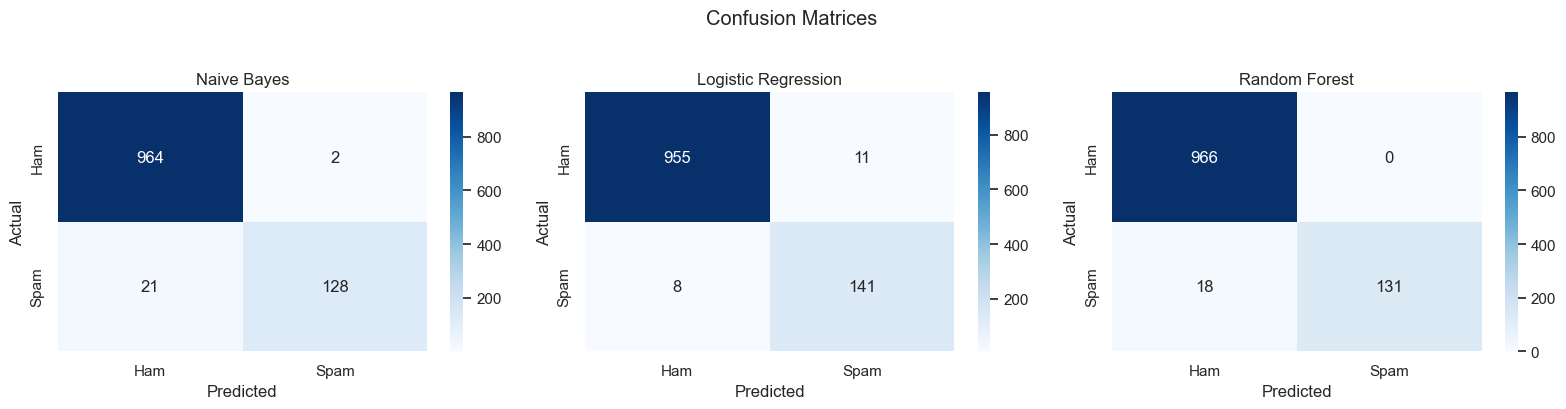

In [23]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (model, X_te)) in zip(axes, fitted.items()):
    preds = model.predict(X_te)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam'],
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', y=1.02)
plt.tight_layout()
plt.show()

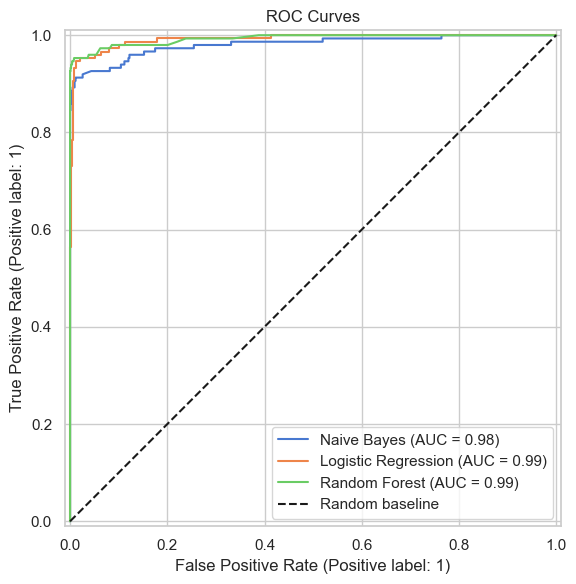

In [24]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, (model, X_te) in fitted.items():
    RocCurveDisplay.from_estimator(model, X_te, y_test, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [25]:
# Classification report for the best model (by F1 — better metric than accuracy for imbalanced classes)
best_name = results_df['F1'].idxmax()
best_model, best_X_te = fitted[best_name]

print(f'Best model: {best_name}\n')
print(classification_report(y_test, best_model.predict(best_X_te), target_names=['Ham', 'Spam']))

Best model: Logistic Regression

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.93      0.95      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



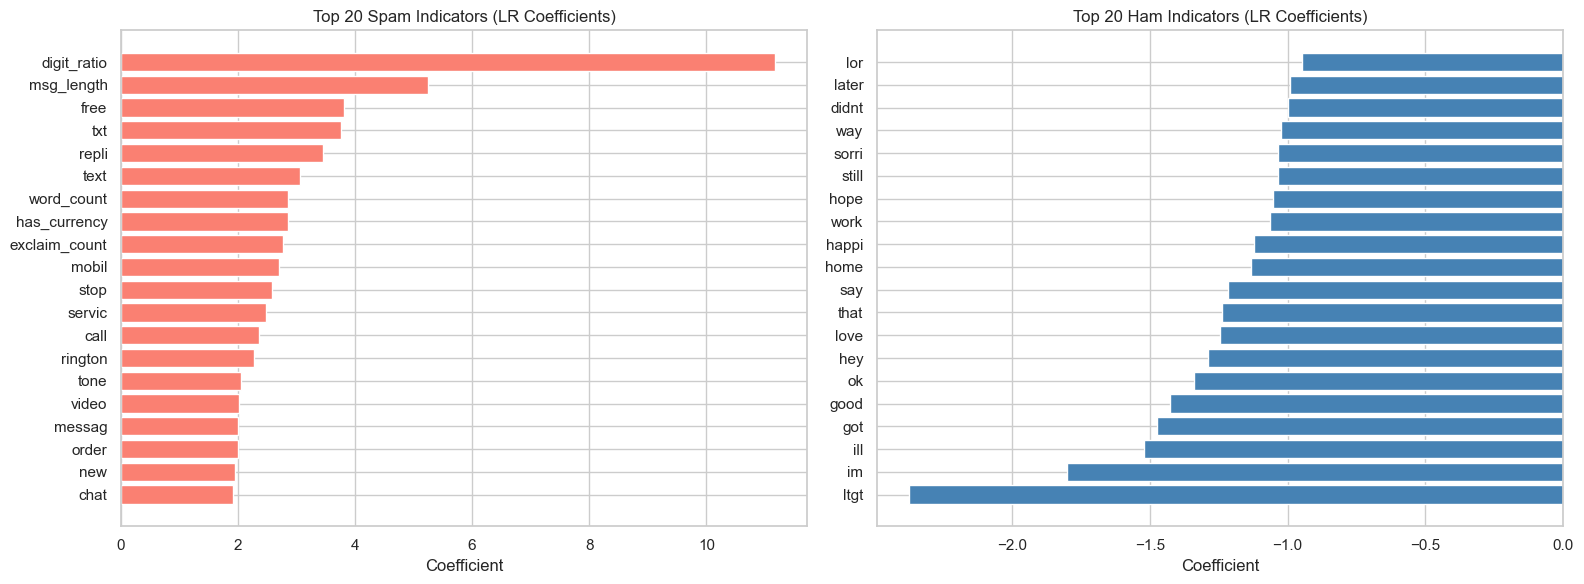

In [26]:
# Top TF-IDF features by log-odds from Logistic Regression
# This shows which words drive spam vs ham predictions
lr_model = fitted['Logistic Regression'][0]
feature_names = tfidf.get_feature_names_out()
meta_names    = list(meta_df.columns)
all_names     = np.concatenate([feature_names, meta_names])

coef = lr_model.coef_[0]
top_spam_idx = np.argsort(coef)[::-1][:20]
top_ham_idx  = np.argsort(coef)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh([all_names[i] for i in top_spam_idx[::-1]],
             [coef[i] for i in top_spam_idx[::-1]], color='salmon')
axes[0].set_title('Top 20 Spam Indicators (LR Coefficients)')
axes[0].set_xlabel('Coefficient')

axes[1].barh([all_names[i] for i in top_ham_idx],
             [coef[i] for i in top_ham_idx], color='steelblue')
axes[1].set_title('Top 20 Ham Indicators (LR Coefficients)')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning

In [27]:
# Tune the best model by F1 score
# F1 chosen as GridSearchCV scoring — balances precision and recall for imbalanced classes

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if best_name == 'Logistic Regression':
    param_grid    = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2']}
    tuning_model  = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    X_tune_train, X_tune_test = X_train_combined, X_test_combined

elif best_name == 'Random Forest':
    param_grid = {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [None, 20, 40],
        'min_samples_split': [2, 5],
    }
    tuning_model  = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
    X_tune_train, X_tune_test = X_train_combined, X_test_combined

else:  # Naive Bayes
    param_grid   = {'alpha': [0.01, 0.05, 0.1, 0.5, 1.0]}
    tuning_model = MultinomialNB()
    X_tune_train, X_tune_test = X_tfidf_train, X_tfidf_test

grid_search = GridSearchCV(
    tuning_model, param_grid,
    cv=cv, scoring='f1',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_tune_train, y_train)

print(f'Best params : {grid_search.best_params_}')
print(f'Best CV F1  : {grid_search.best_score_:.4f}')

Best params : {'C': 100, 'penalty': 'l2'}
Best CV F1  : 0.9471


In [28]:
tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_tune_test)
tuned_proba = tuned_model.predict_proba(X_tune_test)[:, 1]

print(f'Tuned {best_name} — Test Set Results')
print(f"Accuracy  : {accuracy_score(y_test, tuned_preds):.4f}")
print(f"Precision : {precision_score(y_test, tuned_preds):.4f}")
print(f"Recall    : {recall_score(y_test, tuned_preds):.4f}")
print(f"F1        : {f1_score(y_test, tuned_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, tuned_proba):.4f}")
print()
print(classification_report(y_test, tuned_preds, target_names=['Ham', 'Spam']))

Tuned Logistic Regression — Test Set Results
Accuracy  : 0.9874
Precision : 0.9655
Recall    : 0.9396
F1        : 0.9524
ROC-AUC   : 0.9927

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.97      0.94      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



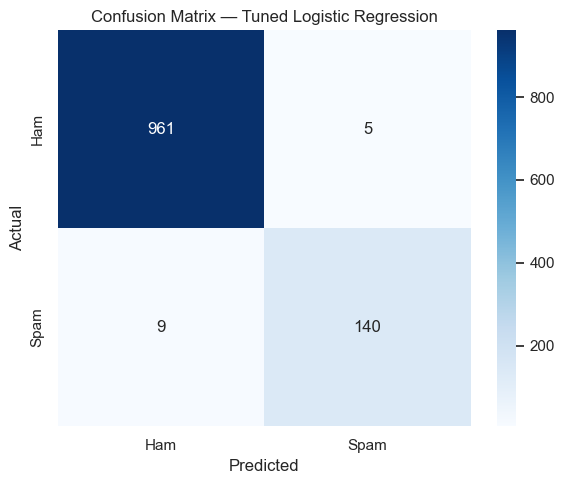

In [29]:
# Final confusion matrix — tuned model
cm_tuned = confusion_matrix(y_test, tuned_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tuned, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.title(f'Confusion Matrix — Tuned {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 11. Inference on Custom Messages

In [30]:
def predict_message(text: str) -> None:
    """
    Run the full preprocessing + feature extraction + prediction pipeline
    on a single new message and print the result with confidence score.
    """
    clean   = preprocess_text(text)
    tfidf_v = tfidf.transform([clean])
    meta_v  = scaler.transform(pd.DataFrame([extract_meta_features(text)]))
    combined = hstack([tfidf_v, csr_matrix(meta_v)])

    # Use the tuned model; fall back to best baseline if tuned model uses TF-IDF only
    if best_name == 'Naive Bayes':
        vec = tfidf_v
    else:
        vec = combined

    pred  = tuned_model.predict(vec)[0]
    proba = tuned_model.predict_proba(vec)[0]

    label = 'SPAM' if pred == 1 else 'HAM'
    conf  = proba[pred]
    print(f'Message : {text}')
    print(f'Result  : {label} (confidence: {conf:.2%})')
    print()


test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are we still on for dinner tonight at 7?",
    "URGENT: Your account has been compromised. Call 08001234567 immediately.",
    "Can you pick up some milk on your way home?",
]

for msg in test_messages:
    predict_message(msg)

Message : Congratulations! You've won a FREE iPhone. Click here to claim now!
Result  : SPAM (confidence: 73.19%)

Message : Hey, are we still on for dinner tonight at 7?
Result  : HAM (confidence: 99.99%)

Message : URGENT: Your account has been compromised. Call 08001234567 immediately.
Result  : SPAM (confidence: 88.50%)

Message : Can you pick up some milk on your way home?
Result  : HAM (confidence: 100.00%)

